<a href="https://colab.research.google.com/github/yakdudi12/DIAO2A/blob/main/TP1_Sokoban_78.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Se importan las dependencias necesarias

In [1]:
"""Importaciones """
try:
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.animation as animation
    from collections import deque
    import heapq
    import time
    import copy
    import pandas as pd
    from pathlib import Path
    from typing import Tuple, List, Set, Callable, Dict, Any
    from IPython.display import display, Image
    from tqdm.auto import tqdm
    try:
        from google.colab import files
    except ImportError:
        files = None  # Permite ejecutar el notebook fuera de Colab.

    cwd = Path.cwd().resolve()
    tp1_dir = cwd if cwd.name.lower() == 'tp1' else cwd / 'TP1'
    MAPS_DIR = tp1_dir / 'mapas'
    OUTPUT_DIR = tp1_dir / 'output'
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    print("Librerías importadas.")
except ImportError as e:
    raise ImportError(f"No se pudo importar una libreria requerida: {e}") from e


Librerías importadas.


c:\Users\santi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Se define SokobanState para traquear los estados al moverse por los nodos.

In [2]:
'''SokobanState'''
try:
    class SokobanState:
        """
        Representacion del estado del juego Sokoban en un momento dado.
        - player: (fila, columna)
        - boxes: tupla de posiciones (fila, columna) de las cajas.
        - walls: conjunto de posiciones de paredes.
        - goals: conjunto de posiciones de objetivos.
        - rows, cols: dimensiones del tablero.
        """
        def __init__(self, player: Tuple[int, int], boxes: Tuple[Tuple[int, int], ...],
                    walls: Set[Tuple[int, int]], goals: Set[Tuple[int, int]],
                    rows: int, cols: int):
            self.player = player
            self.boxes = tuple(sorted(boxes))
            self.walls = walls
            self.goals = goals
            self.rows = rows
            self.cols = cols

        def __hash__(self):
            return hash((self.player, self.boxes))

        def __eq__(self, other):
            return (isinstance(other, SokobanState) and
                    self.player == other.player and self.boxes == other.boxes)

        def is_goal(self) -> bool:
            """Verifica si todas las cajas estan en objetivos."""
            return all(box in self.goals for box in self.boxes)

        def get_successors(self) -> List[Tuple['SokobanState', str]]:
            """Genera los sucesores moviendo al jugador (o empujando una caja)."""
            successors = []
            r, c = self.player
            moves = [(-1, 0, 'U'), (1, 0, 'D'), (0, -1, 'L'), (0, 1, 'R')]

            for dr, dc, action in moves:
                nr, nc = r + dr, c + dc
                if not (0 <= nr < self.rows and 0 <= nc < self.cols):
                    continue
                if (nr, nc) in self.walls:
                    continue

                if (nr, nc) in self.boxes:
                    br, bc = nr + dr, nc + dc
                    if (not (0 <= br < self.rows and 0 <= bc < self.cols) or
                            (br, bc) in self.walls or (br, bc) in self.boxes):
                        continue
                    new_boxes = list(self.boxes)
                    idx = new_boxes.index((nr, nc))
                    new_boxes[idx] = (br, bc)
                    new_boxes = tuple(new_boxes)
                    successors.append((SokobanState((nr, nc), new_boxes, self.walls, self.goals, self.rows, self.cols), action + '!'))
                else:
                    successors.append((SokobanState((nr, nc), self.boxes, self.walls, self.goals, self.rows, self.cols), action))
            return successors

        def __repr__(self):
            grid = [[' ' for _ in range(self.cols)] for _ in range(self.rows)]
            for (r, c) in self.walls:
                grid[r][c] = '#'
            for (r, c) in self.goals:
                if grid[r][c] == ' ':
                    grid[r][c] = '.'
            for (r, c) in self.boxes:
                if (r, c) in self.goals:
                    grid[r][c] = '*'
                else:
                    grid[r][c] = '$'
            pr, pc = self.player
            if (pr, pc) in self.goals:
                grid[pr][pc] = '+'
            else:
                grid[pr][pc] = '@'
            return '\n'.join(''.join(row) for row in grid)

    print("Clase SokobanState definida.")
except ValueError as e:
    print("No se pudo crear correctamente el estado de Sokoban")


Clase SokobanState definida.


## Se definen funciones para procesar los mapas Sokoban.

In [3]:
def preprocess_map_for_board(map_str: str) -> str:
    """
    Convierte el mapa original (con _, G, B, P y espacios externos)
    al formato esperado por load_map_from_string:
      - '_'  -> ' '  (suelo)
      - 'G'  -> '.'  (objetivo)
      - 'B'  -> '$'  (caja)
      - 'P'  -> '@'  (jugador)
      - '#'  -> '#'  (pared)
      - cualquier otro carácter (incluidos espacios externos) -> '#'
    """
    lines = map_str.strip('\n').split('\n')
    processed = []
    for line in lines:
        # Si la línea está vacía la saltamos
        if not line.strip():
            continue
        new_line = []
        for ch in line:
            if ch == '#':
                new_line.append('#')
            elif ch == '_':
                new_line.append(' ')   # suelo
            elif ch == 'G':
                new_line.append('.')   # objetivo
            elif ch == 'B':
                new_line.append('$')   # caja
            elif ch == 'P':
                new_line.append('@')   # jugador
            else:
                new_line.append('#')   # todo lo demás (espacios) = pared
        processed.append(''.join(new_line))
    return '\n'.join(processed)

def load_map_from_string(map_str: str) -> SokobanState:
    """
    Convierte un mapa en texto a un objeto SokobanState.
    Simbolos: # pared, . objetivo, $ caja, * caja sobre objetivo,
              @ jugador, + jugador sobre objetivo.
    """
    lines = [line.rstrip('\n') for line in map_str.strip().split('\n')]
    rows = len(lines)
    cols = max(len(line) for line in lines)
    walls = set()
    goals = set()
    boxes = []
    player = None
    player_count = 0

    for r, line in enumerate(lines):
        # Las lineas mas cortas se completan con PARED, no con espacios:
        # rellenar con ' ' generaria suelo fantasma fuera del tablero y el
        # jugador podria escaparse del mapa.
        line = line.ljust(cols, '#')
        for c, ch in enumerate(line):
            if ch == '#':
                walls.add((r, c))
            elif ch == '.':
                goals.add((r, c))
            elif ch == '$':
                boxes.append((r, c))
            elif ch == '*':
                boxes.append((r, c))
                goals.add((r, c))
            elif ch == '@':
                player = (r, c)
                player_count += 1
            elif ch == '+':
                player = (r, c)
                player_count += 1
                goals.add((r, c))

    if player_count != 1:
        raise ValueError("El mapa debe contener exactamente un jugador (@ o +).")
    if not boxes:
        raise ValueError("El mapa debe contener al menos una caja ($ o *).")
    if len(boxes) != len(goals):
        raise ValueError("La cantidad de cajas debe coincidir con la de objetivos.")

    return SokobanState(player, tuple(boxes), walls, goals, rows, cols)


## Se carga el mapa_raw y los mapas guardados como .txt

In [4]:
# ------------------------------------------------------------
# MAPA ESPECÍFICO DEL PROBLEMA (15x10)
# ------------------------------------------------------------
mapa_raw = """
      ###
      #G#
  #####G#####
 ##_________##
##__#_#_#_#__##
#__##_____##__#
#_##__#_#__##_#
#______BPB____#
####__###__####
   ####_###
"""

# Preprocesar y cargar el mapa por defecto
mapa_procesado = preprocess_map_for_board(mapa_raw)
initial_state = load_map_from_string(mapa_procesado)

# Cargar tambien todos los mapas .txt de TP1/mapas. Esos archivos ya usan
# el formato estandar de Sokoban, por lo que no necesitan preprocesamiento.
mapas_estados = {'mapa_default': initial_state}
mapas_invalidos = []
for map_path in sorted(MAPS_DIR.glob('*.txt')):
    try:
        mapas_estados[map_path.stem] = load_map_from_string(
            map_path.read_text(encoding='utf-8')
        )
    except (OSError, ValueError) as exc:
        mapas_invalidos.append((map_path.name, str(exc)))

if mapas_invalidos:
    detalle = '\n'.join(f'  - {nombre}: {error}' for nombre, error in mapas_invalidos)
    raise ValueError(f'Se encontraron mapas invalidos:\n{detalle}')

print(f"Mapas cargados: {len(mapas_estados)} (1 por defecto + {len(mapas_estados)-1} archivos)")


Mapas cargados: 101 (1 por defecto + 100 archivos)


## Se definen las heurísticas

In [5]:
# ============================================================
# HEURISTICAS
# ============================================================
try:
    def manhattan(p1: Tuple[int, int], p2: Tuple[int, int]) -> int:
        return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

    def h1_sum_boxes_to_goal(state: SokobanState) -> int:
        """
        Suma, para cada caja, la distancia Manhattan al objetivo mas cercano.
        Admisible: cada empuje mueve una caja una celda y cuesta 1 movimiento,
        asi que la suma es cota inferior de la cantidad de movimientos.
        """
        total = 0
        for box in state.boxes:
            min_dist = min(manhattan(box, goal) for goal in state.goals)
            total += min_dist
        return total

    def h2_plus_player_distance(state: SokobanState) -> int:
        """
        h1 + los movimientos que el jugador necesita para ponerse a empujar.
        Para empujar una caja el jugador solo necesita quedar ADYACENTE a ella,
        es decir (dist - 1) movimientos; sumar dist completa sobreestima en 1
        y rompe la admisibilidad (ej: jugador en (r,c), caja en (r,c+1),
        objetivo en (r,c+2) -> costo real 1, pero h1 + dist = 2).
        """
        h1 = h1_sum_boxes_to_goal(state)
        min_player_to_box = float('inf')
        for box in state.boxes:
            if box not in state.goals:
                dist = manhattan(state.player, box)
                if dist < min_player_to_box:
                    min_player_to_box = dist
        if min_player_to_box == float('inf'):
            return h1
        return h1 + max(0, min_player_to_box - 1)

    def h3_non_admissible(state: SokobanState) -> int:
        return h1_sum_boxes_to_goal(state) * 2

    def is_corner_deadlock(state) -> bool:
        '''Reconocer si la caja se trabo en alguna posicion inamovible'''
        for box in state.boxes:
            if box in state.goals:
                continue   # ya está en destino, no importa si está en una esquina
            r, c = box
            up = (r - 1, c) in state.walls
            down = (r + 1, c) in state.walls
            left = (r, c - 1) in state.walls
            right = (r, c + 1) in state.walls
            if (up and left) or (up and right) or (down and left) or (down and right):
                return True
        return False

    def h4_corner_aware(state) -> float:
        if is_corner_deadlock(state):
            return float('inf')
        return h1_sum_boxes_to_goal(state)

    def h5_h2_plus_corner(state) -> float:
        if is_corner_deadlock(state):
            return float('inf')
        return h2_plus_player_distance(state)

    print("Heurísticas definidas.")

except ValueError as e:
    print("ERROR: No se lograron cargar las Heuristicas")

Heurísticas definidas.


## Se definen los algoritmos de busqueda
### Desinformados:  
    * DFS
    * BFS
### Informados: 
    * Greedy
    * Astar
    * IDDS

In [6]:
# Todas las funciones devuelven:
# (success, path, cost, expanded_nodes, frontier_max, elapsed_time)

def bfs_search(initial_state, max_iter: int = 200000):
    start_time = time.perf_counter()
    expanded = 0
    visited = {initial_state}
    frontier = deque([(initial_state, [])])
    frontier_max = 1

    while frontier and expanded < max_iter:
        state, path = frontier.popleft()  # Sale el mas antiguo, menos profundo
        if state.is_goal():
            return True, path, len(path), expanded, frontier_max, time.perf_counter() - start_time
        expanded += 1
        for next_state, action in state.get_successors():
            if next_state not in visited:
                visited.add(next_state)
                frontier.append((next_state, path + [action]))
                frontier_max = max(frontier_max, len(frontier))

    return False, [], 0, expanded, frontier_max, time.perf_counter() - start_time


def dfs_search(initial_state, max_iter: int = 200000):
    start_time = time.perf_counter()
    expanded = 0
    visited = {initial_state}
    frontier = [(initial_state, [])]
    frontier_max = 1

    while frontier and expanded < max_iter:
        state, path = frontier.pop()  # Sale el ultimo, mas profundo
        if state.is_goal():
            return True, path, len(path), expanded, frontier_max, time.perf_counter() - start_time
        expanded += 1
        for next_state, action in state.get_successors():
            if next_state not in visited:
                visited.add(next_state)
                frontier.append((next_state, path + [action]))
                frontier_max = max(frontier_max, len(frontier))

    return False, [], 0, expanded, frontier_max, time.perf_counter() - start_time


def greedy_search(initial_state, heuristic: Callable, max_iter: int = 200000):
    if heuristic is None:
        raise ValueError("Greedy necesita heuristica")

    start_time = time.perf_counter()
    expanded = 0
    visited = {initial_state}
    counter = 0
    heap = [(heuristic(initial_state), counter, initial_state, [])]
    frontier_max = 1

    while heap and expanded < max_iter:
        _, _, state, path = heapq.heappop(heap)
        if state.is_goal():
            return True, path, len(path), expanded, frontier_max, time.perf_counter() - start_time
        expanded += 1
        for next_state, action in state.get_successors():
            if next_state not in visited:
                visited.add(next_state)
                counter += 1
                heapq.heappush(heap, (heuristic(next_state), counter, next_state, path + [action]))
                frontier_max = max(frontier_max, len(heap))

    return False, [], 0, expanded, frontier_max, time.perf_counter() - start_time


def a_star_search(initial_state, heuristic: Callable, max_iter: int = 200000):
    if heuristic is None:
        raise ValueError("A* necesita heuristica")

    start_time = time.perf_counter()
    expanded = 0
    best_cost = {}
    counter = 0
    heap = [(heuristic(initial_state), counter, initial_state, [], 0)]
    frontier_max = 1

    while heap and expanded < max_iter:
        _, _, state, path, cost = heapq.heappop(heap)
        if state.is_goal():
            return True, path, cost, expanded, frontier_max, time.perf_counter() - start_time
        if state in best_cost and best_cost[state] <= cost:
            continue
        best_cost[state] = cost
        expanded += 1
        for next_state, action in state.get_successors():
            next_cost = cost + 1
            if next_state not in best_cost or next_cost < best_cost[next_state]:
                counter += 1
                priority = next_cost + heuristic(next_state)
                heapq.heappush(heap, (priority, counter, next_state, path + [action], next_cost))
                frontier_max = max(frontier_max, len(heap))

    return False, [], 0, expanded, frontier_max, time.perf_counter() - start_time


def iddfs_search(initial_state, max_iter: int = 200000, max_depth: int = 100):
    start_time = time.perf_counter()
    budget_exhausted = [False]

    def depth_limited_search(state, limit, depth, path, visited, expanded_local):
        if state.is_goal():
            return 'success', path
        if depth == limit:
            return 'cutoff', None

        cutoff_occurred = False
        for next_state, action in state.get_successors():
            if expanded_local[0] >= max_iter:
                budget_exhausted[0] = True
                return 'cutoff', None
            if next_state not in visited:
                visited.add(next_state)
                expanded_local[0] += 1
                result, result_path = depth_limited_search(
                    next_state, limit, depth + 1, path + [action], visited, expanded_local
                )
                if result == 'success':
                    return 'success', result_path
                if result == 'cutoff':
                    cutoff_occurred = True
                visited.remove(next_state)

        return ('cutoff', None) if cutoff_occurred else ('failure', None)

    expanded = 0
    frontier_max = 0
    for depth_limit in range(max_depth + 1):
        visited = {initial_state}
        expanded_local = [expanded]
        result, path = depth_limited_search(
            initial_state, depth_limit, 0, [], visited, expanded_local
        )
        expanded = expanded_local[0]
        frontier_max = max(frontier_max, depth_limit + 1)
        if result == 'success':
            return True, path, len(path), expanded, frontier_max, time.perf_counter() - start_time
        if budget_exhausted[0] or result == 'failure':
            break

    return False, [], 0, expanded, frontier_max, time.perf_counter() - start_time

## Se realiza los experimentos sobre todos los mapas

In [7]:
# ============================================================
# EXPERIMENTACION SOBRE TODOS LOS MAPAS
# ============================================================
algoritmos_informados = {
    "Greedy": greedy_search,
    "A*": a_star_search,
}
heuristicas = {
    "h1": h1_sum_boxes_to_goal,
    "h2": h2_plus_player_distance,
    "h3_no_admisible": h3_non_admissible,
    "h4_corner": h4_corner_aware,
    "h5_h2_corner": h5_h2_plus_corner,
}

MAX_ITER = 200000
MAX_DEPTH = 100

configuraciones = [
    ("BFS", "N/A", bfs_search, {"max_iter": MAX_ITER}),
    ("DFS", "N/A", dfs_search, {"max_iter": MAX_ITER}),
    ("IDDFS", "N/A", iddfs_search, {"max_iter": MAX_ITER, "max_depth": MAX_DEPTH}),
] + [
    (alg, h_name, search_function, {"heuristic": h_func, "max_iter": MAX_ITER})
    for alg, search_function in algoritmos_informados.items()
    for h_name, h_func in heuristicas.items()
]

resultados = []

def registrar(mapa_nombre, estado, alg, h_name, resultado):
    success, path, cost, expanded, frontier, elapsed = resultado
    if success:
        motivo_finalizacion = 'Solucion'
    elif expanded >= MAX_ITER:
        motivo_finalizacion = 'Limite_Nodos'
    elif alg == 'IDDFS':
        motivo_finalizacion = 'Limite_Profundidad'
    else:
        motivo_finalizacion = 'Sin_Solucion'

    resultados.append({
        'Mapa': mapa_nombre,
        'Filas': estado.rows,
        'Columnas': estado.cols,
        'Cajas': len(estado.boxes),
        'Algoritmo': alg,
        'Heuristica': '' if h_name == 'N/A' else h_name,
        'Exito': success,
        'Motivo_Finalizacion': motivo_finalizacion,
        'Costo_Movimientos': float(cost) if success else np.nan,
        'Empujes': sum(action.endswith('!') for action in path) if success else np.nan,
        'Nodos_Expandidos': expanded,
        'Frontera_Maxima': frontier,
        'Tiempo_Segundos': elapsed,
    })

total_ejecuciones = len(mapas_estados) * len(configuraciones)

with tqdm(total=total_ejecuciones, desc='Ejecutando busquedas', unit='busqueda') as progreso:
    for mapa_nombre, estado in mapas_estados.items():
        for alg, h_name, search_function, search_arguments in configuraciones:
            metodo = alg if h_name == 'N/A' else f'{alg}-{h_name}'
            progreso.set_postfix(mapa=mapa_nombre, metodo=metodo, refresh=False)
            resultado = search_function(estado, **search_arguments)
            registrar(mapa_nombre, estado, alg, h_name, resultado)
            progreso.update(1)

df = pd.DataFrame(resultados)
df['Metodo'] = np.where(
    df['Heuristica'].eq(''),
    df['Algoritmo'],
    df['Algoritmo'] + '-' + df['Heuristica'],
)

def percentil_95(serie):
    return serie.quantile(0.95)

resumen = df.groupby('Metodo', as_index=False).agg(
    Mapas=('Mapa', 'nunique'),
    Exitos=('Exito', 'sum'),
    Tasa_Exito_pct=('Exito', lambda s: 100 * s.mean()),
    Tiempo_Mediana_s=('Tiempo_Segundos', 'median'),
    Tiempo_P95_s=('Tiempo_Segundos', percentil_95),
    Nodos_Mediana=('Nodos_Expandidos', 'median'),
    Nodos_P95=('Nodos_Expandidos', percentil_95),
    Frontera_P95=('Frontera_Maxima', percentil_95),
    Costo_Mediana=('Costo_Movimientos', 'median'),
    Empujes_Mediana=('Empujes', 'median'),
).sort_values(['Tasa_Exito_pct', 'Tiempo_Mediana_s'], ascending=[False, True])

print('\n' + '='*100)
print('RESUMEN ESTADISTICO POR METODO')
print('='*100)
print(resumen.round(4).to_string(index=False))

csv_columns = [
    'Mapa', 'Filas', 'Columnas', 'Cajas', 'Algoritmo', 'Heuristica',
    'Exito', 'Motivo_Finalizacion', 'Costo_Movimientos', 'Empujes',
    'Nodos_Expandidos', 'Frontera_Maxima', 'Tiempo_Segundos',
]
csv_path = OUTPUT_DIR / 'resultados_experimentos.csv'
df[csv_columns].to_csv(csv_path, index=False)
print(f'\nResultados guardados en {csv_path}')

Ejecutando busquedas: 100%|██████████| 1313/1313 [00:53<00:00, 24.62busqueda/s, mapa=mapa_099, metodo=A*-h5_h2_corner]      


RESUMEN ESTADISTICO POR METODO
                Metodo  Mapas  Exitos  Tasa_Exito_pct  Tiempo_Mediana_s  Tiempo_P95_s  Nodos_Mediana  Nodos_P95  Frontera_P95  Costo_Mediana  Empujes_Mediana
      Greedy-h4_corner    101     101        100.0000            0.0007        0.0020           84.0      306.0          66.0           26.0              8.0
   Greedy-h5_h2_corner    101     101        100.0000            0.0008        0.0028           84.0      284.0         132.0           26.0             10.0
Greedy-h3_no_admisible    101     101        100.0000            0.0009        0.0038          147.0      598.0          76.0           26.0              8.0
             Greedy-h1    101     101        100.0000            0.0012        0.0043          147.0      598.0          76.0           26.0              8.0
             Greedy-h2    101     101        100.0000            0.0012        0.0044          128.0      548.0         200.0           26.0             10.0
                   D

## Se realizan los gráficos estáticos utilizando matplotlib

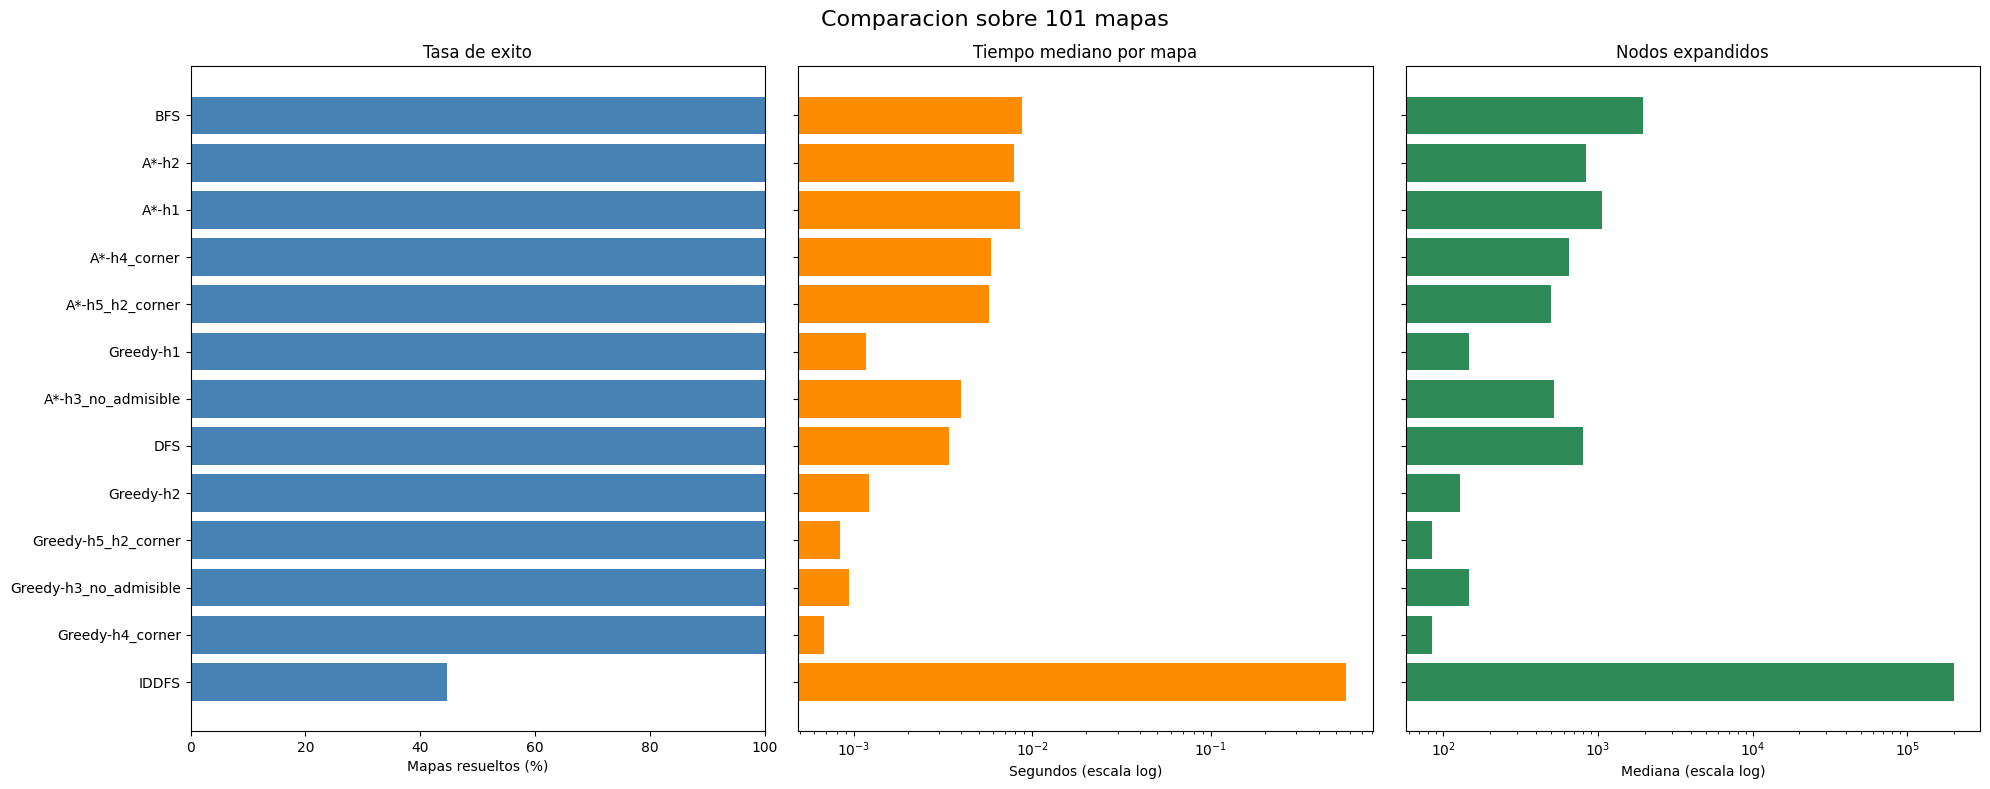

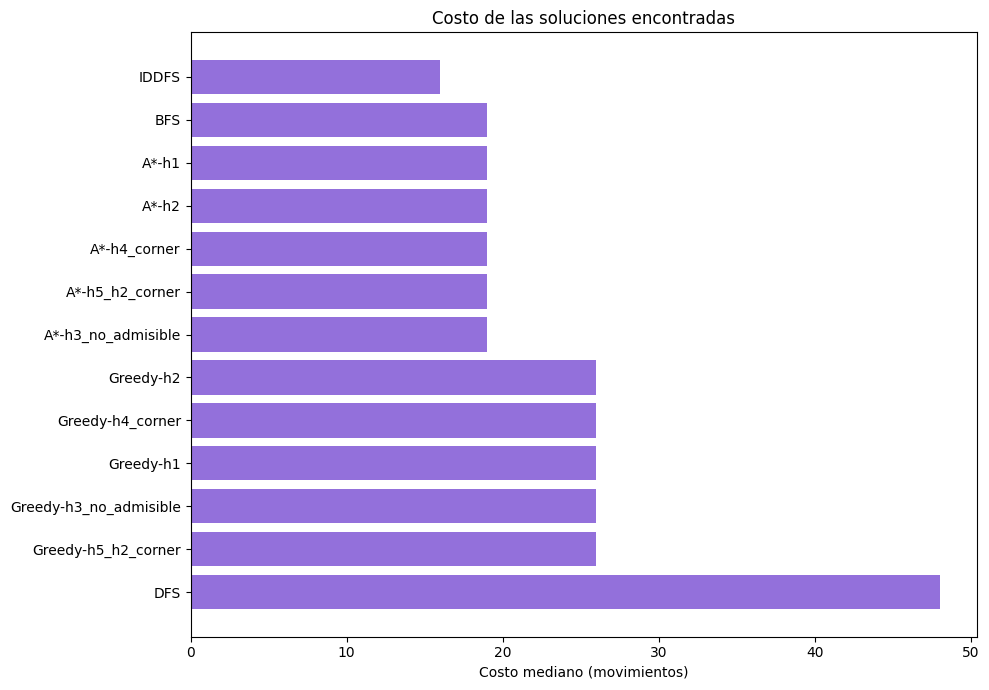

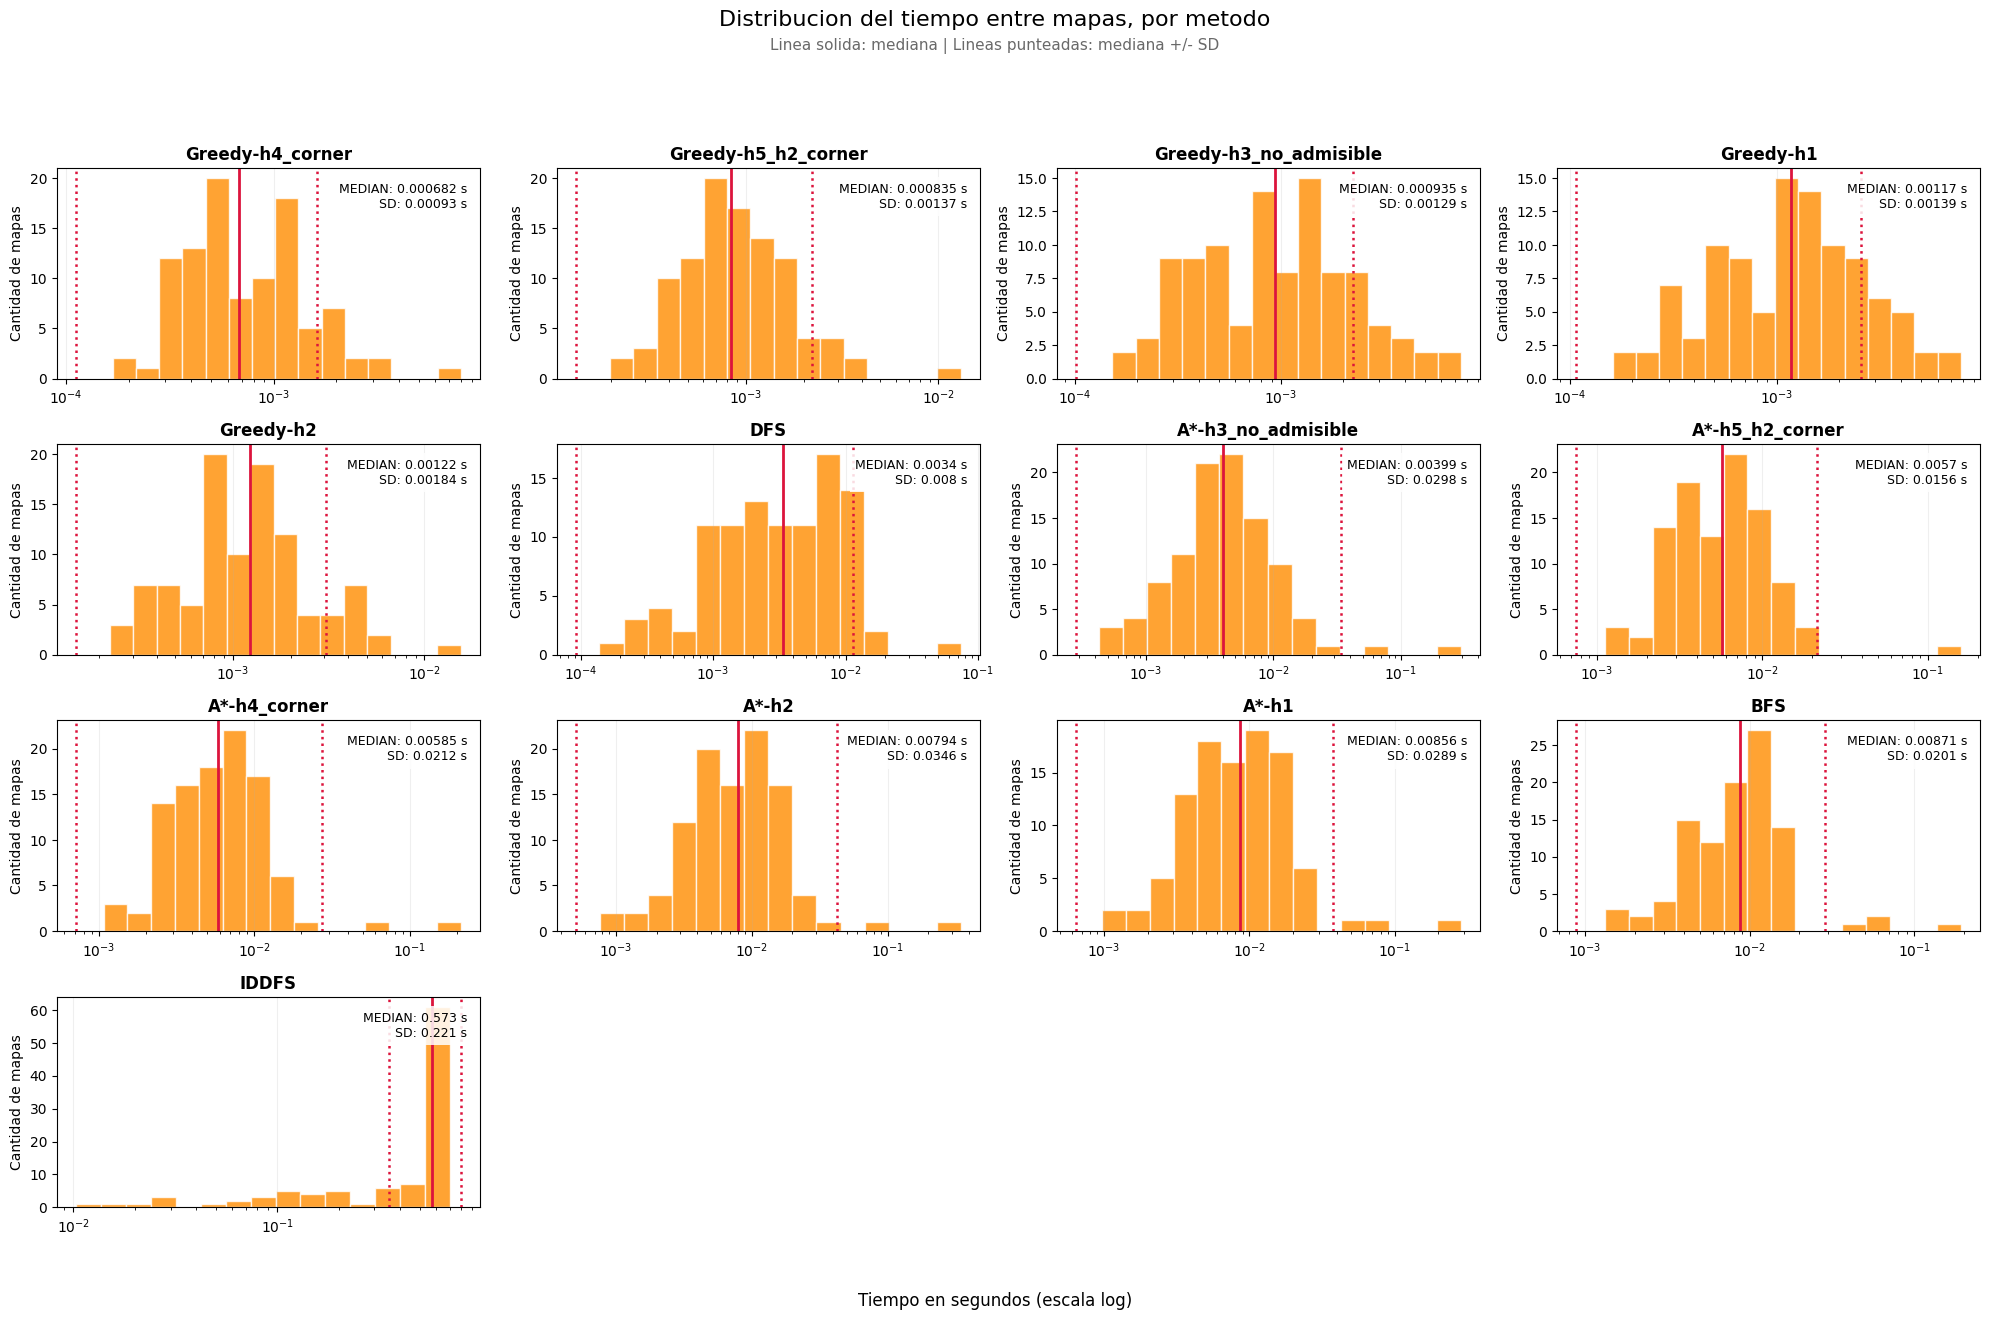

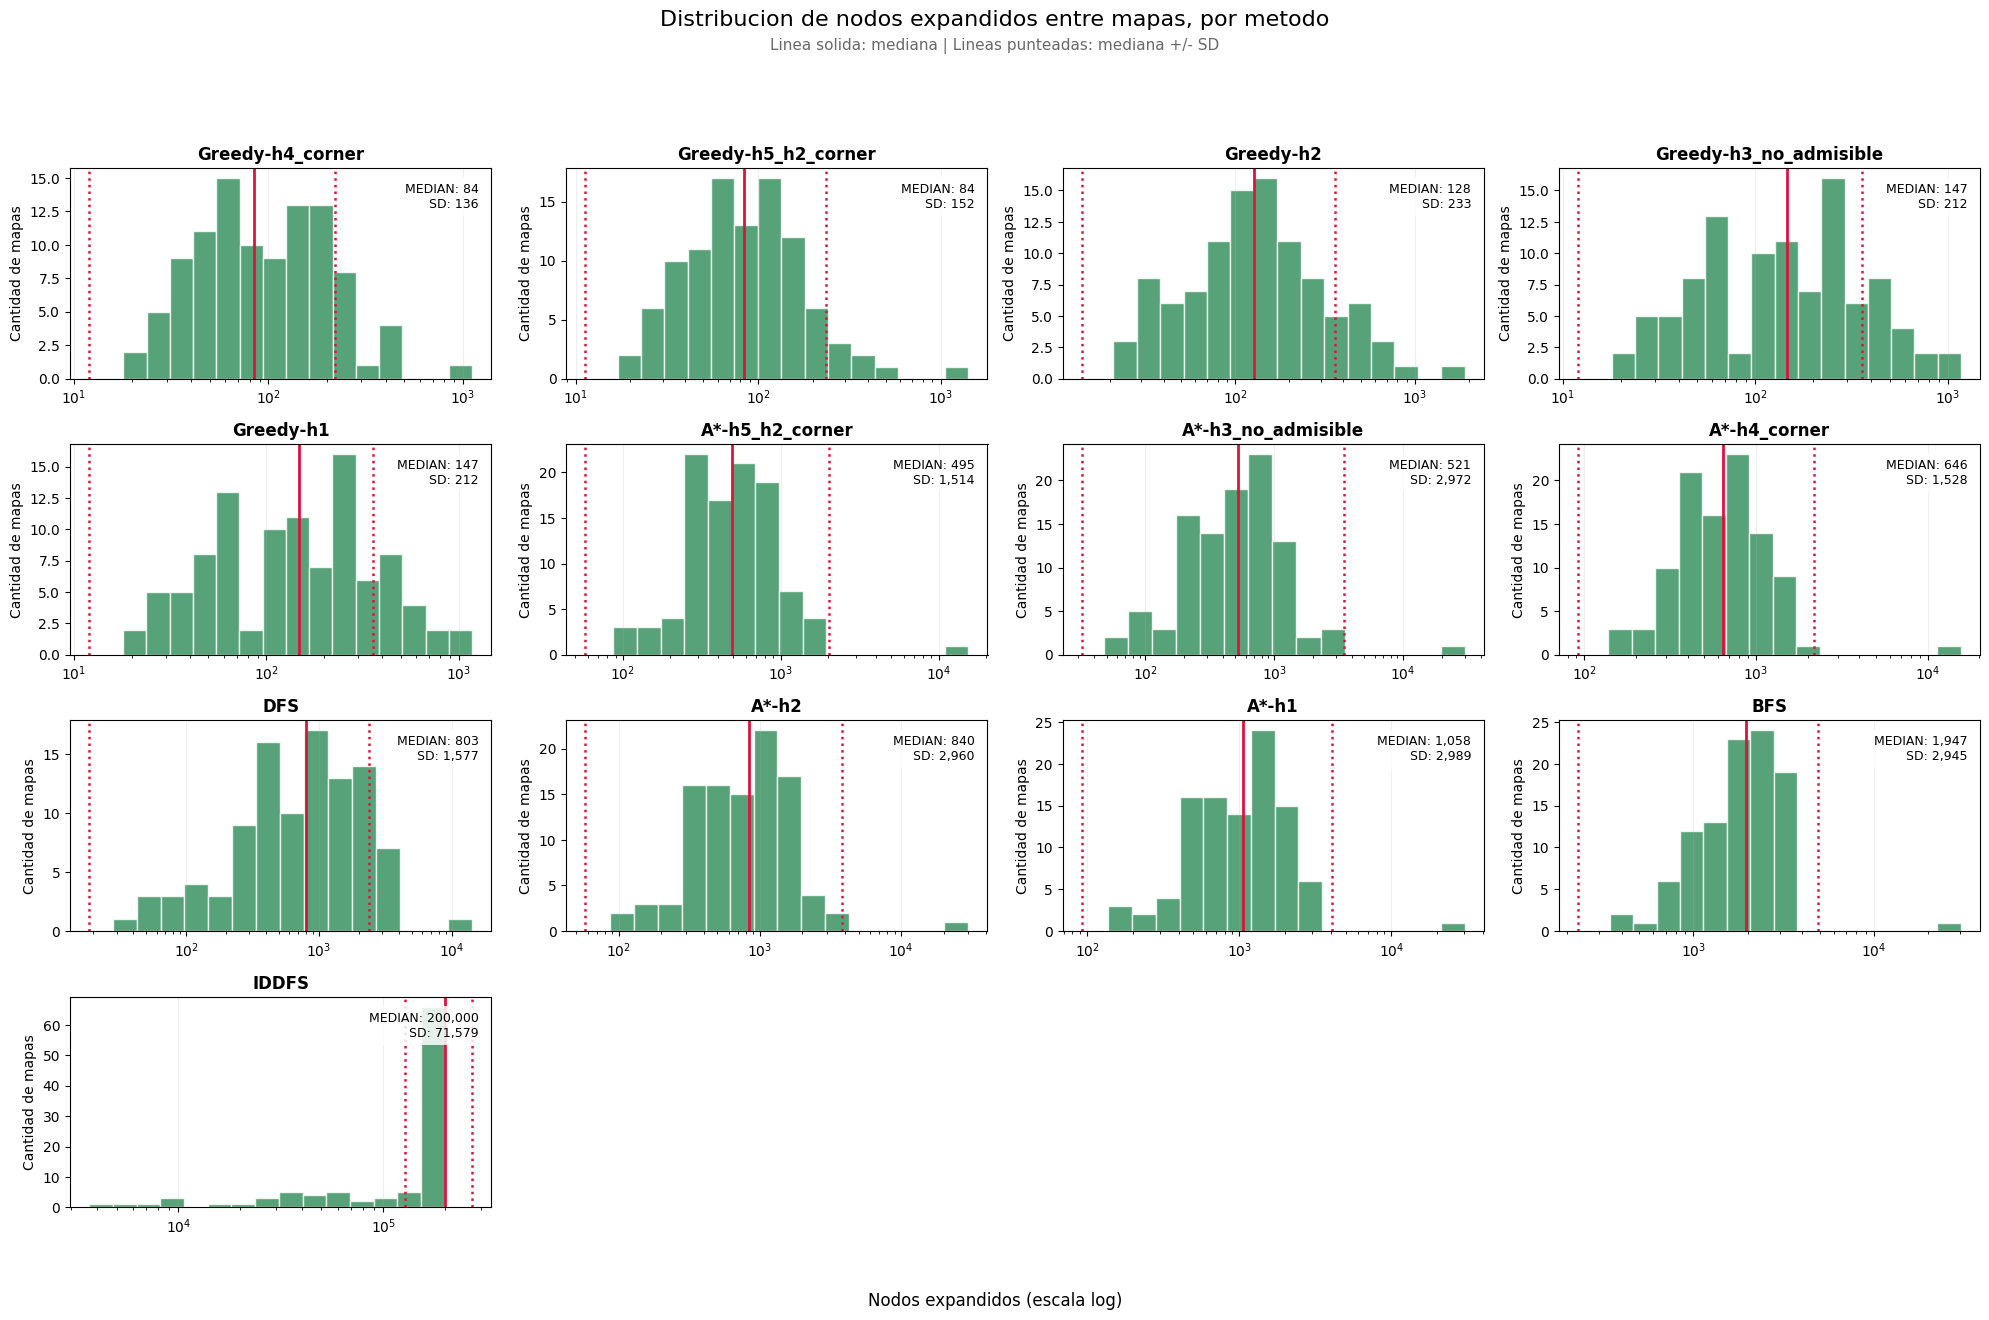

Graficos guardados en D:\doctoradoitbarepo\DIAO2A\TP1\output\graficos_comparativos.png, D:\doctoradoitbarepo\DIAO2A\TP1\output\costo_soluciones.png, D:\doctoradoitbarepo\DIAO2A\TP1\output\distribucion_tiempo_por_metodo.png y D:\doctoradoitbarepo\DIAO2A\TP1\output\distribucion_nodos_por_metodo.png


C:\Users\santi\AppData\Local\Temp\ipykernel_7240\1711714059.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


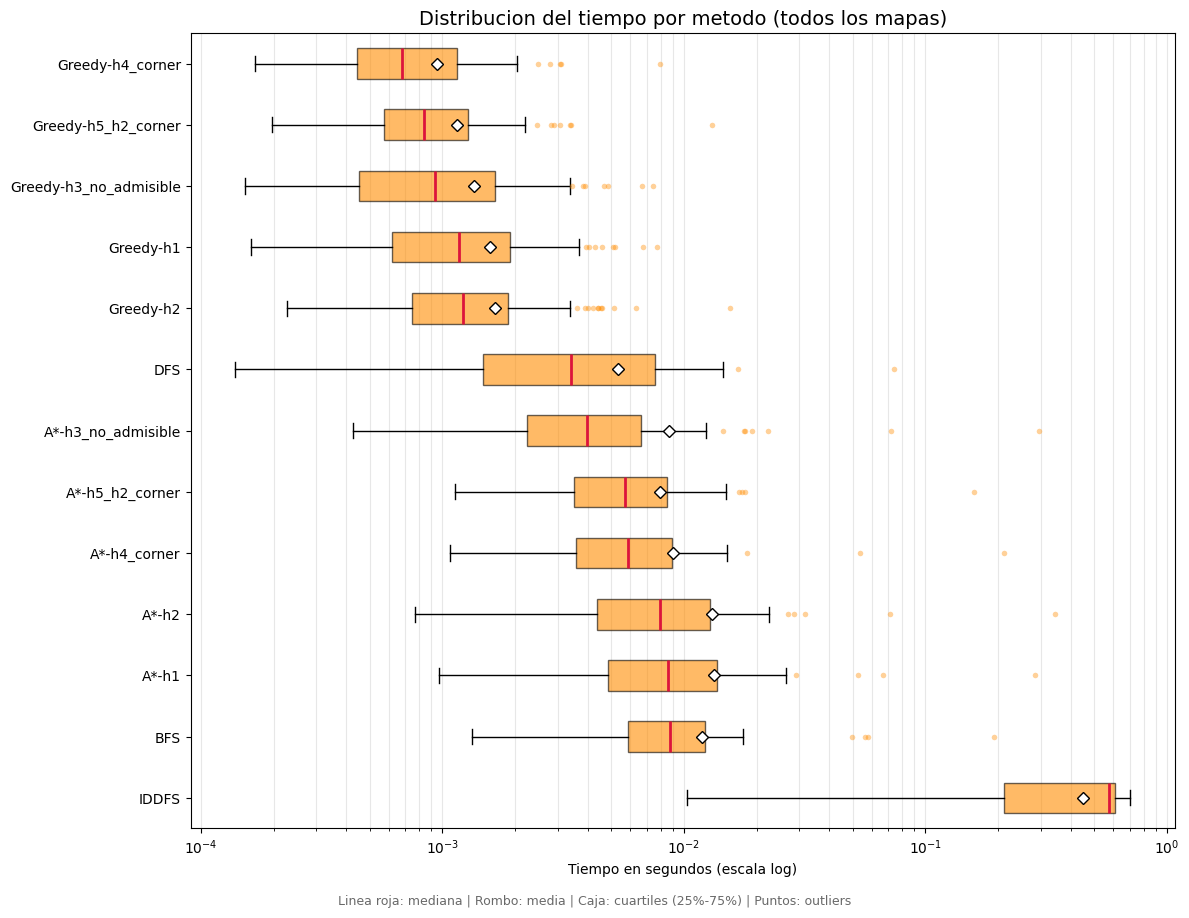

C:\Users\santi\AppData\Local\Temp\ipykernel_7240\1711714059.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


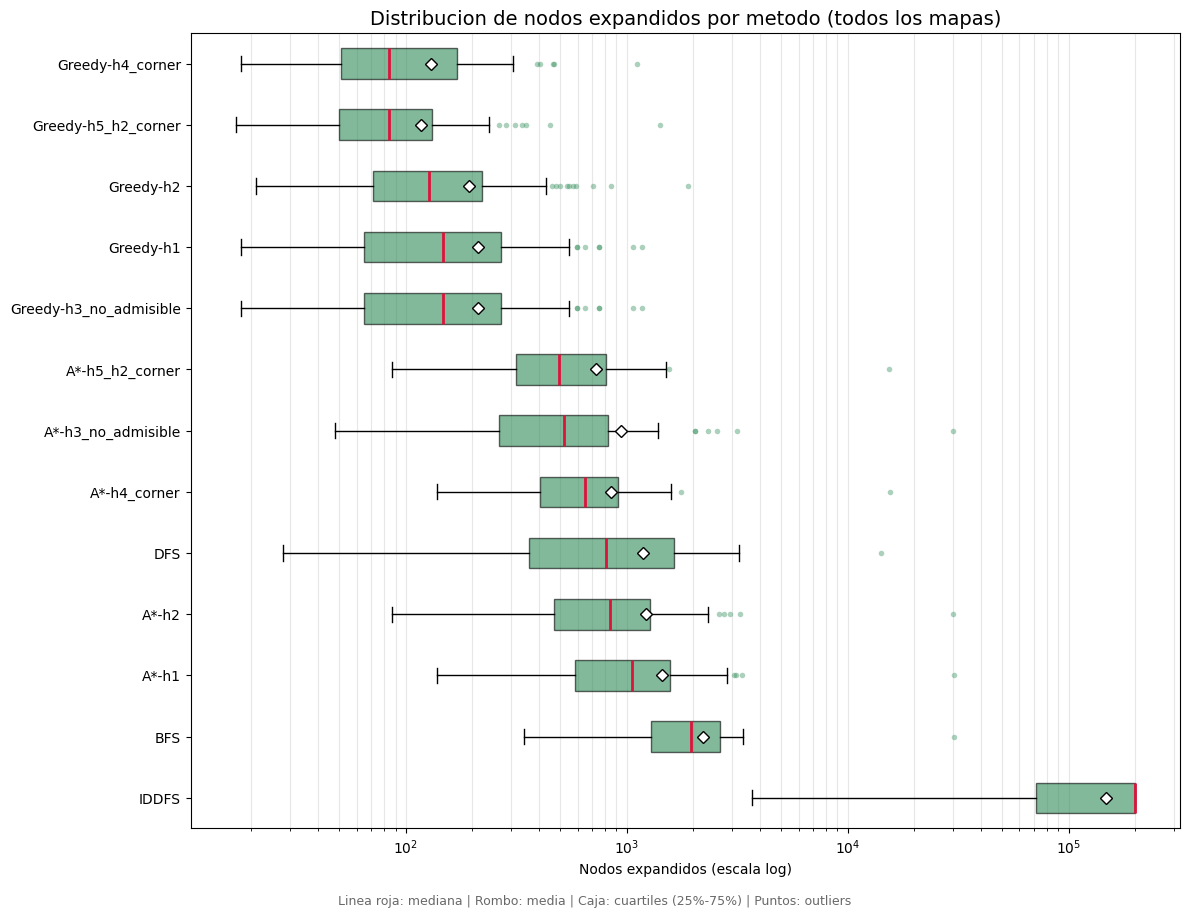

Boxplots guardados en D:\doctoradoitbarepo\DIAO2A\TP1\output\boxplot_tiempo_por_metodo.png y D:\doctoradoitbarepo\DIAO2A\TP1\output\boxplot_nodos_por_metodo.png


In [10]:

chart_path = OUTPUT_DIR / 'graficos_comparativos.png'
cost_chart_path = OUTPUT_DIR / 'costo_soluciones.png'
time_distribution_chart_path = OUTPUT_DIR / 'distribucion_tiempo_por_metodo.png'
nodes_distribution_chart_path = OUTPUT_DIR / 'distribucion_nodos_por_metodo.png'

plot_data = resumen.sort_values('Tasa_Exito_pct', ascending=True)
fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

axes[0].barh(plot_data['Metodo'], plot_data['Tasa_Exito_pct'], color='steelblue')
axes[0].set_title('Tasa de exito')
axes[0].set_xlabel('Mapas resueltos (%)')
axes[0].set_xlim(0, 100)

axes[1].barh(plot_data['Metodo'], plot_data['Tiempo_Mediana_s'], color='darkorange')
axes[1].set_title('Tiempo mediano por mapa')
axes[1].set_xlabel('Segundos (escala log)')
axes[1].set_xscale('log')

axes[2].barh(plot_data['Metodo'], plot_data['Nodos_Mediana'], color='seagreen')
axes[2].set_title('Nodos expandidos')
axes[2].set_xlabel('Mediana (escala log)')
axes[2].set_xscale('log')

fig.suptitle(f'Comparacion sobre {len(mapas_estados)} mapas', fontsize=16)
plt.tight_layout()
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()

cost_data = resumen.sort_values('Costo_Mediana', ascending=False)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(cost_data['Metodo'], cost_data['Costo_Mediana'], color='mediumpurple')
ax.set_title('Costo de las soluciones encontradas')
ax.set_xlabel('Costo mediano (movimientos)')
plt.tight_layout()
plt.savefig(cost_chart_path, dpi=150, bbox_inches='tight')
plt.show()

# Cada metodo se muestra en su propio panel para que la forma de la
# distribucion y la dispersion no queden ocultas por los otros metodos.
def plot_distributions_by_method(
    column, sort_column, title, xlabel, output_path, color, formatter
):
    methods = resumen.sort_values(sort_column)['Metodo'].tolist()
    columns = 4
    rows = (len(methods) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(20, 3.3 * rows))
    axes = np.asarray(axes).reshape(-1)

    for index, (ax, method) in enumerate(zip(axes, methods)):
        values = df.loc[df['Metodo'] == method, column].dropna().to_numpy()
        minimum, maximum = values.min(), values.max()
        if minimum == maximum:
            minimum, maximum = minimum / 1.2, maximum * 1.2
        bins = np.geomspace(minimum, maximum, 16)
        median = np.median(values)
        std = values.std(ddof=1) if len(values) > 1 else 0
        lower_std = max(median - std, minimum / 1.5)
        upper_std = median + std

        ax.hist(values, bins=bins, color=color, alpha=0.8, edgecolor='white')
        ax.axvline(
            lower_std, color='crimson', linewidth=1.8, linestyle=':'
        )
        ax.axvline(
            upper_std, color='crimson', linewidth=1.8, linestyle=':'
        )
        ax.axvline(
            median, color='crimson', linewidth=2
        )
        ax.text(
            0.97, 0.93, f'MEDIAN: {formatter(median)}\nSD: {formatter(std)}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox={'facecolor': 'white', 'alpha': 0.85, 'edgecolor': 'none'}
        )
        ax.set_title(method, fontweight='bold')
        ax.set_xscale('log')
        ax.set_ylabel('Cantidad de mapas')
        ax.grid(axis='x', alpha=0.2)

    for ax in axes[len(methods):]:
        ax.axis('off')

    fig.suptitle(title, fontsize=16, y=0.995)
    fig.text(
        0.5, 0.965, 'Linea solida: mediana | Lineas punteadas: mediana +/- SD',
        ha='center', fontsize=11, color='dimgray'
    )
    fig.supxlabel(xlabel)
    plt.tight_layout(rect=(0, 0.03, 1, 0.93))
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_distributions_by_method(
    'Tiempo_Segundos', 'Tiempo_Mediana_s',
    'Distribucion del tiempo entre mapas, por metodo',
    'Tiempo en segundos (escala log)', time_distribution_chart_path, 'darkorange',
    lambda value: f'{value:.3g} s'
)
plot_distributions_by_method(
    'Nodos_Expandidos', 'Nodos_Mediana',
    'Distribucion de nodos expandidos entre mapas, por metodo',
    'Nodos expandidos (escala log)', nodes_distribution_chart_path, 'seagreen',
    lambda value: f'{value:,.0f}'
)

print(
    f'Graficos guardados en {chart_path}, {cost_chart_path}, '
    f'{time_distribution_chart_path} y {nodes_distribution_chart_path}'
)

time_boxplot_path = OUTPUT_DIR / 'boxplot_tiempo_por_metodo.png'
nodes_boxplot_path = OUTPUT_DIR / 'boxplot_nodos_por_metodo.png'

def plot_boxplot_by_method(column, sort_column, title, xlabel, output_path, color):
    """
    Genera un boxplot horizontal, un método por fila, ordenado según
    sort_column (para que se lea de mejor a peor de arriba a abajo).
    """
    methods = resumen.sort_values(sort_column, ascending=False)['Metodo'].tolist()
    data = [df.loc[df['Metodo'] == m, column].dropna().to_numpy() for m in methods]

    fig, ax = plt.subplots(figsize=(12, 0.55 * len(methods) + 2))

    bp = ax.boxplot(
        data,
        vert=False,
        patch_artist=True,
        labels=methods,
        showmeans=True,
        meanprops={
            'marker': 'D', 'markerfacecolor': 'white',
            'markeredgecolor': 'black', 'markersize': 6,
        },
        medianprops={'color': 'crimson', 'linewidth': 2},
        flierprops={
            'marker': 'o', 'markersize': 4,
            'markerfacecolor': color, 'markeredgecolor': 'none', 'alpha': 0.4,
        },
    )
    for box in bp['boxes']:
        box.set(facecolor=color, alpha=0.6, edgecolor='black')

    ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=14)
    ax.grid(axis='x', alpha=0.3, which='both')
    fig.text(
        0.5, 0.005,
        'Linea roja: mediana | Rombo: media | Caja: cuartiles (25%-75%) | Puntos: outliers',
        ha='center', fontsize=9, color='dimgray'
    )
    plt.tight_layout(rect=(0, 0.02, 1, 1))
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_boxplot_by_method(
    'Tiempo_Segundos', 'Tiempo_Mediana_s',
    'Distribucion del tiempo por metodo (todos los mapas)',
    'Tiempo en segundos (escala log)', time_boxplot_path, 'darkorange'
)
plot_boxplot_by_method(
    'Nodos_Expandidos', 'Nodos_Mediana',
    'Distribucion de nodos expandidos por metodo (todos los mapas)',
    'Nodos expandidos (escala log)', nodes_boxplot_path, 'seagreen'
)

print(f'Boxplots guardados en {time_boxplot_path} y {nodes_boxplot_path}')

## Se realiza el .gif de la solución estándar utilizando A* con h2


Generando GIF de la solución con A* + h2...
Solución encontrada con costo 77 movimientos.


KeyboardInterrupt: 

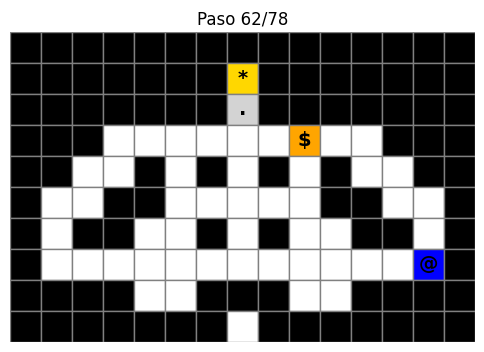

In [9]:


def save_solution_gif(initial_state, path, filename='solucion.gif'):
    if not path:
        print("No hay camino para generar GIF.")
        return

    states = [initial_state]
    current = initial_state
    for action in path:
        for nxt, act in current.get_successors():
            if act == action:
                current = nxt
                states.append(current)
                break

    fig, ax = plt.subplots(figsize=(6, 6))

    def render_state(state, ax):
        ax.clear()
        grid = [[' ' for _ in range(state.cols)] for _ in range(state.rows)]
        for (r, c) in state.walls:
            grid[r][c] = '#'
        for (r, c) in state.goals:
            if grid[r][c] == ' ':
                grid[r][c] = '.'
        for (r, c) in state.boxes:
            if (r, c) in state.goals:
                grid[r][c] = '*'
            else:
                grid[r][c] = '$'
        pr, pc = state.player
        if (pr, pc) in state.goals:
            grid[pr][pc] = '+'
        else:
            grid[pr][pc] = '@'

        colors = {
            ' ': 'white', '#': 'black', '.': 'lightgray',
            '$': 'orange', '*': 'gold', '@': 'blue', '+': 'cyan'
        }
        for r in range(state.rows):
            for c in range(state.cols):
                ch = grid[r][c]
                color = colors.get(ch, 'white')
                ax.add_patch(plt.Rectangle((c, -r-1), 1, 1, color=color, ec='gray'))
                ax.text(c+0.5, -r-0.5, ch, ha='center', va='center', fontsize=14, fontweight='bold')
        ax.set_xlim(0, state.cols)
        ax.set_ylim(-state.rows, 0)
        ax.set_aspect('equal')
        ax.axis('off')

    def update(frame):
        render_state(states[frame], ax)
        ax.set_title(f'Paso {frame+1}/{len(states)}')

    ani = animation.FuncAnimation(fig, update, frames=len(states), repeat=False)
    ani.save(filename, writer='pillow', fps=2)
    plt.close()
    print(f"GIF guardado como '{filename}'")

print("\nGenerando GIF de la solución con A* + h2...")
success, path, cost, expanded, frontier, elapsed = a_star_search(
    initial_state, heuristic=h2_plus_player_distance, max_iter=200000
)

gif_path = OUTPUT_DIR / 'solucion_A_estrella.gif'
if success:
    print(f"Solución encontrada con costo {cost} movimientos.")
    save_solution_gif(initial_state, path, gif_path)
    display(Image(filename=str(gif_path)))
else:
    print("No se encontró solución para generar el GIF.")

# ============================================================
# DESCARGA DE ARCHIVOS
# ============================================================
if files is not None:
    print("\nDescargando archivos generados...")
    for output_path in (
        gif_path, chart_path, cost_chart_path,
        time_distribution_chart_path, nodes_distribution_chart_path,
        csv_path
    ):
        if output_path.exists():
            files.download(str(output_path))
        else:
            print(f"No se encontro '{output_path}' para descargar.")

print("\n" + "="*80)
print("PROCESO COMPLETADO")
print("="*80)